# Flight Delay Prediction Project
**Name:** Alexander Ruiz

**Goal:** The goal of this project is to predict whether a flight will be delayed using historical airline data. A flight is considered delayed if the arrival delay exceeds 15 minutes.

In [1]:
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
zip_path = "flights_sample_3m.csv.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("./")

df = pd.read_csv("flights_sample_3m.csv")
print("Shape:", df.shape)
df.head()

Shape: (3000000, 32)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


**Observation:** 
The dataset was loaded successfully with 3 million rows and 32 columns, which shows it is a large dataset. Looking at the first few rows, I can see a mix of categorical features (like airline and airport) and numerical features (like distance and time), which will need to be prepared for modeling.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

**Observation:** The dataset contains a mix of numerical and categorical features, including flight timing, airline information, and delay-related variables. Many columns are related to delays, which could be useful for prediction. The dataset is also large, using over 700 MB of memory, so efficiency will be important when processing the data.

In [4]:
df.isnull().sum().sort_values(ascending=False)

CANCELLATION_CODE          2920860
DELAY_DUE_LATE_AIRCRAFT    2466137
DELAY_DUE_CARRIER          2466137
DELAY_DUE_SECURITY         2466137
DELAY_DUE_NAS              2466137
DELAY_DUE_WEATHER          2466137
ARR_DELAY                    86198
ELAPSED_TIME                 86198
AIR_TIME                     86198
WHEELS_ON                    79944
TAXI_IN                      79944
ARR_TIME                     79942
WHEELS_OFF                   78806
TAXI_OUT                     78806
DEP_DELAY                    77644
DEP_TIME                     77615
CRS_ELAPSED_TIME                14
DEST_CITY                        0
CRS_DEP_TIME                     0
DEST                             0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
AIRLINE                          0
AIRLINE_DOT                      0
FL_DATE                          0
AIRLINE_CODE                     0
DIVERTED            

**Observation:**
There are many missing values in the dataset, especially in columns related to delays and cancellations. Some columns have a very large number of missing values, which likely means those events did not occur. This shows that I will need to clean or remove certain columns before training the model.

In [5]:
df["DELAYED"] = (df["ARR_DELAY"] > 15).astype(int)
df["DELAYED"].value_counts()

DELAYED
0    2484711
1     515289
Name: count, dtype: int64

**Observation:** A new column called DELAYED was created to turn the problem into a binary classification task, where 1 means delayed and 0 means on time. Most flights are not delayed, which shows that the dataset is imbalanced and this will affect how the models perform.

In [6]:
drop_cols = [
    "ARR_DELAY",
    "DEP_DELAY",
    "ELAPSED_TIME",
    "AIR_TIME",
    "DELAY_DUE_CARRIER",
    "DELAY_DUE_WEATHER",
    "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY",
    "DELAY_DUE_LATE_AIRCRAFT",
    "DEP_TIME",
    "TAXI_OUT",
    "WHEELS_OFF",
    "WHEELS_ON",
    "TAXI_IN",
    "ARR_TIME",
    "CANCELLATION_CODE"
]
df = df.drop(columns=drop_cols, errors="ignore")

**Note:** Columns that could cause data leakage or are based on post flight information were removed from the dataset. This ensures that the model only uses information that would be available before the flight, making the predictions more realistic.

In [7]:
# Feature engineering
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
df["DAY_OF_WEEK"] = df["FL_DATE"].dt.dayofweek
df["MONTH"] = df["FL_DATE"].dt.month
df["DEPARTURE_HOUR"] = df["CRS_DEP_TIME"] // 100
df["IS_WEEKEND"] = df["DAY_OF_WEEK"].isin([5, 6]).astype(int)
df["ROUTE"] = df["ORIGIN"] + "_" + df["DEST"]

**Observation:** New features were created from the flight date and departure time, including day of week, month, departure hour, and whether the flight occurs on a weekend. These features help capture time-based patterns that may influence flight delays.

In [8]:
# Additional time based features
def get_time_of_day(hour):
    if hour < 6:
        return "Early Morning"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["TIME_OF_DAY"] = df["DEPARTURE_HOUR"].apply(get_time_of_day)
df["IS_PEAK_HOUR"] = df["DEPARTURE_HOUR"].isin([7, 8, 9, 16, 17, 18]).astype(int)

**Observation:** Additional time based features were created, including time of day and peak hour indicators. These features help capture patterns related to busy travel periods, which may increase the likelihood of delays.

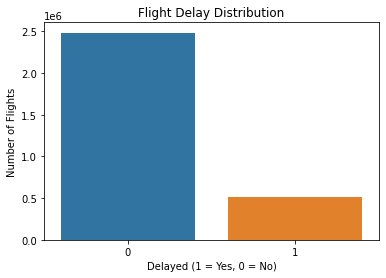

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="DELAYED", data=df)
plt.title("Flight Delay Distribution")
plt.xlabel("Delayed (1 = Yes, 0 = No)")
plt.ylabel("Number of Flights")
plt.show()

**Obsercvation:** This visualization shows the distribution of delayed and non-delayed flights. The dataset is highly imbalanced, with significantly more on-time flights than delayed flights. This imbalance can affect model performance, especially when predicting delayed flights.

In [10]:
#Sample
df_sample = df.sample(200000, random_state=42).copy()
print(df_sample.shape)

(200000, 24)


**Observation:** A sample of 200,000 rows was taken from the full dataset to reduce computation time. This makes the model training faster while still keeping enough data to capture important patterns.

In [11]:
# Route frequency feeature
route_counts = df_sample["ROUTE"].value_counts()
df_sample["ROUTE_FREQ"] = df_sample["ROUTE"].map(route_counts)
print(df_sample[["ROUTE", "ROUTE_FREQ"]].head())

           ROUTE  ROUTE_FREQ
2945667  MCO_JFK         132
2352586  FLL_DTW          79
1531260  SMF_LAS         118
941910   OKC_DTW           5
2582125  FLL_SFO          34


**Observation New Feature:** A new feature called ROUTE_FREQ was created to represent how frequently each route appears in the dataset. This helps capture route popularity and possible congestion, which may influence flight delays.

In [12]:
#Select Feature
features = [
    "AIRLINE",
    "ORIGIN",
    "DEST",
    "DISTANCE",
    "CRS_ELAPSED_TIME",
    "DAY_OF_WEEK",
    "MONTH",
    "DEPARTURE_HOUR",
    "IS_WEEKEND",
    "TIME_OF_DAY",
    "IS_PEAK_HOUR",
    "ROUTE_FREQ"
]

X = df_sample[features]
y = df_sample["DELAYED"]

print(X.shape)
print(X.isnull().sum())

(200000, 12)
AIRLINE             0
ORIGIN              0
DEST                0
DISTANCE            0
CRS_ELAPSED_TIME    1
DAY_OF_WEEK         0
MONTH               0
DEPARTURE_HOUR      0
IS_WEEKEND          0
TIME_OF_DAY         0
IS_PEAK_HOUR        0
ROUTE_FREQ          0
dtype: int64


**Observation:** A set of features was selected that would be available before the flight, including airline, airports, distance, and time related features. Only one missing value remained in the selected features, which needed to be handled before model training.

In [13]:
# Handling misssing values
X["CRS_ELAPSED_TIME"] = X["CRS_ELAPSED_TIME"].fillna(X["CRS_ELAPSED_TIME"].median())
X["DISTANCE"] = X["DISTANCE"].fillna(X["DISTANCE"].median())
print(X.isnull().sum())

AIRLINE             0
ORIGIN              0
DEST                0
DISTANCE            0
CRS_ELAPSED_TIME    0
DAY_OF_WEEK         0
MONTH               0
DEPARTURE_HOUR      0
IS_WEEKEND          0
TIME_OF_DAY         0
IS_PEAK_HOUR        0
ROUTE_FREQ          0
dtype: int64


/tmp/ipykernel_222/376635493.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["CRS_ELAPSED_TIME"] = X["CRS_ELAPSED_TIME"].fillna(X["CRS_ELAPSED_TIME"].median())
/tmp/ipykernel_222/376635493.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["DISTANCE"] = X["DISTANCE"].fillna(X["DISTANCE"].median())


**Observation:** Missing values in the numerical features were filled using the median. After this step, there are no missing values remaining, so the dataset is ready for model training.

**Warning note:** It’s a Pandas warning about modifying a copy of the data. It doesn’t affect the results, and the missing values were handled correctly.

In [14]:
#Encoding
X = pd.get_dummies(
    X,
    columns=["AIRLINE", "ORIGIN", "DEST", "TIME_OF_DAY"],
    drop_first=True
)
print("Shape after encoding:", X.shape)

Shape after encoding: (200000, 781)


**Observation:** Categorical features like airline and airport were converted into numerical values using one hot encoding.
This increased the number of features significantly, which shows there are many unique airlines and airports in the dataset.

In [15]:
#Train Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape, X_test.shape)

(160000, 781) (40000, 781)


**Observation:** The dataset was split into training and testing sets, with 80% of the data used for training and 20% used for testing. Stratification was applied to ensure that both sets maintain the same proportion of delayed and non-delayed flights, which is important due to class imbalance.The dataset was split into training and testing sets, with 80% of the data used for training and 20% used for testing. Stratification was applied to ensure that both sets maintain the same proportion of delayed and non-delayed flights, which is important due to class imbalance.

In [16]:
#SGD Classifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
sgd_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    random_state=42
)
sgd_model.fit(X_train, y_train)
y_pred_sgd = sgd_model.predict(X_test)
print("SGD Classifier Accuracy:", accuracy_score(y_test, y_pred_sgd))
print(classification_report(y_test, y_pred_sgd))

SGD Classifier Accuracy: 0.42745
              precision    recall  f1-score   support

           0       0.88      0.36      0.51     33112
           1       0.20      0.75      0.31      6888

    accuracy                           0.43     40000
   macro avg       0.54      0.56      0.41     40000
weighted avg       0.76      0.43      0.48     40000



**Observation:** The SGD model was used as a baseline classifier. Although it has lower overall accuracy, it performs well at identifying delayed flights, with a high recall for the delayed class.This is important because the goal of the project is to detect delays rather than simply maximize accuracy.

In [17]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.814275
              precision    recall  f1-score   support

           0       0.83      0.97      0.90     33112
           1       0.29      0.06      0.09      6888

    accuracy                           0.81     40000
   macro avg       0.56      0.51      0.49     40000
weighted avg       0.74      0.81      0.76     40000



**Observation:** The Random Forest model achieved higher overall accuracy, but struggled to identify delayed flights, with very low recall. This suggests the model is biased toward predicting the majority class (on time flights), limiting its effectiveness for this problem.

In [18]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.827825
              precision    recall  f1-score   support

           0       0.83      1.00      0.91     33112
           1       0.56      0.00      0.00      6888

    accuracy                           0.83     40000
   macro avg       0.69      0.50      0.45     40000
weighted avg       0.78      0.83      0.75     40000



**Observation:** The Gradient Boosting model produced the highest accuracy, but failed to detect delayed flights, with a recall of 0%. This indicates the model is heavily biased toward the majority class and is not suitable for predicting delays.

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
xgb_model = XGBClassifier(
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    n_estimators=100
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.62835
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     33112
           1       0.25      0.57      0.35      6888

    accuracy                           0.63     40000
   macro avg       0.56      0.60      0.54     40000
weighted avg       0.77      0.63      0.67     40000



**Observation:** The XGBoost model provided a better balance between accuracy and recall. While its accuracy is lower than some models, it was able to detect a meaningful number of delayed flights, making it more practical for this task.

### Models Table
SGD Classifier:
Accuracy: 43%
Recall (Delayed): 75%

Random Forest:
Accuracy: 81%
Recall (Delayed): 5%

Gradient Boosting:
Accuracy: 83%
Recall (Delayed): 0%

XGBoost:
Accuracy: 64%
Recall (Delayed): 55%

### Model Comparison:
The results show that models with higher accuracy are not necessarily better for this problem. Random Forest and Gradient Boosting achieved high accuracy but performed poorly at detecting delayed flights due to the imbalanced dataset. The SGD model achieved the highest recall, making it the most effective at identifying delayed flights, but it had lower overall accuracy. The XGBoost model provided a better balance between accuracy and recall, making it a strong overall option for predicting both delayed and non-delayed flights. Overall, this highlights the importance of using multiple evaluation metrics when working with imbalanced data.

In [20]:
#Threshold Tuning (SGD)
from sklearn.metrics import classification_report
y_probs = sgd_model.predict_proba(X_test)[:, 1]
#lower 
threshold = 0.5
y_pred_custom = (y_probs > threshold).astype(int)
print("Threshold:", threshold)
print(classification_report(y_test, y_pred_custom))

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.88      0.36      0.51     33112
           1       0.20      0.75      0.31      6888

    accuracy                           0.43     40000
   macro avg       0.54      0.56      0.41     40000
weighted avg       0.76      0.43      0.48     40000



In [21]:
# Threshold Tuning (XGBoost)
from sklearn.metrics import classification_report
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.5  # try lower than 0.5
y_pred_xgb_custom = (y_probs_xgb > threshold).astype(int)
print("Threshold:", threshold)
print(classification_report(y_test, y_pred_xgb_custom))

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     33112
           1       0.25      0.57      0.35      6888

    accuracy                           0.63     40000
   macro avg       0.56      0.60      0.54     40000
weighted avg       0.77      0.63      0.67     40000



**Threshold Observation:**
These results show the importance of using multiple metrics for imbalanced datasets, since higher accuracy does not always mean a better model. Threshold tuning was applied to both SGD and XGBoost. The SGD model already had high recall (75%), so adjusting the threshold did not significantly improve performance. For XGBoost, the default threshold (0.5) provided a balanced result with 63% accuracy and 57% recall. Lowering the threshold to 0.4 increased recall to 82%, but reduced accuracy to 44%. This highlights the tradeoff between accuracy and recall. Lower thresholds help detect more delays but also increase false positives, showing how model behavior can be adjusted based on the goal.

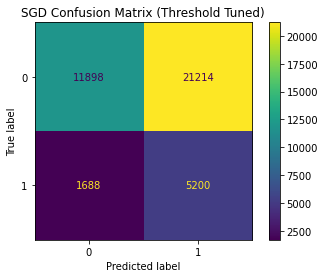

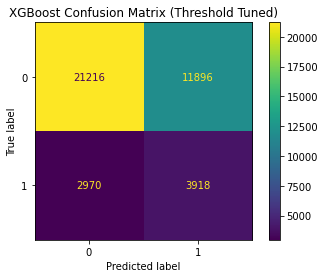

In [22]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# SGD
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom)
plt.title("SGD Confusion Matrix (Threshold Tuned)")
plt.show()
# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_custom)
plt.title("XGBoost Confusion Matrix (Threshold Tuned)")
plt.show()

**Matrix Observation:**
The confusion matrices show clear differences between the models. The SGD model has high recall, meaning it correctly identifies most delayed flights, but it also produces many false positives, so it tends to over-predict delays.The XGBoost model is more balanced, with fewer false positives, but it misses more delayed flights, resulting in lower recall. This highlights the tradeoff between recall and precision. SGD is better for detecting delays, while XGBoost provides more balanced predictions. With threshold tuning, XGBoost can be adjusted to increase recall, showing how model behavior can be changed depending on the goal.

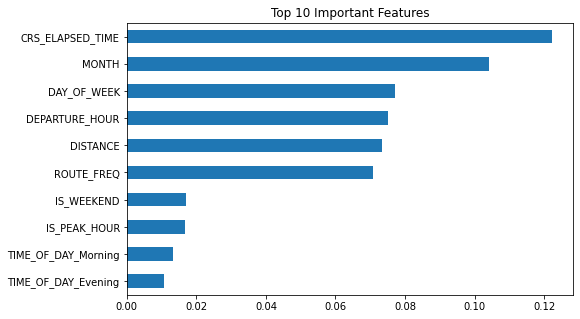

In [23]:
#Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
importances = rf_model.feature_importances_
feature_names = X.columns
feat_importance = pd.Series(importances, index=feature_names)
# top 10 features
top_features = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

**Top 10 Feature:** 
The feature importance results show which variables have the biggest impact on predicting flight delays. CRS_ELAPSED_TIME is the most important feature, suggesting that longer scheduled flights may be more likely to experience delays. Month is also a strong factor, indicating that delays can vary by season. Time related features such as day of the week and departure hour also play an important role, showing that delays depend on when flights are scheduled. Distance and route frequency also contribute, meaning certain routes and longer flights can influence delays. Overall, this shows that both scheduling and route characteristics are important in predicting delays.

In [24]:
import joblib
# Save models
joblib.dump(sgd_model, "sgd_flight_delay_model.pkl")
joblib.dump(xgb_model, "xgb_flight_delay_model.pkl")
# Save feature columns
joblib.dump(X.columns.tolist(), "model_columns.pkl")
print("SGD model, XGBoost model, and columns saved.")

SGD model, XGBoost model, and columns saved.


**Note:** The trained models and feature columns were saved using joblib. This allows the models to be reused later for predictions without retraining and ensures that new input data matches the correct feature structure.

In [25]:
test_flight = pd.DataFrame([{
    "AIRLINE": "Delta Air Lines Inc.",
    "ORIGIN": "ATL",
    "DEST": "JFK",
    "DISTANCE": 760,
    "CRS_ELAPSED_TIME": 150,
    "DAY_OF_WEEK": 4,
    "MONTH": 12,
    "DEPARTURE_HOUR": 18,
    "IS_WEEKEND": 0,
    "TIME_OF_DAY": "Evening",
    "IS_PEAK_HOUR": 1,
    "ROUTE_FREQ": 50
}])
test_flight

,AIRLINE,ORIGIN,DEST,DISTANCE,CRS_ELAPSED_TIME,DAY_OF_WEEK,MONTH,DEPARTURE_HOUR,IS_WEEKEND,TIME_OF_DAY,IS_PEAK_HOUR,ROUTE_FREQ
0,Delta Air Lines Inc.,ATL,JFK,760,150,4,12,18,0,Evening,1,50


In [26]:
test_encoded = pd.get_dummies(
    test_flight,
    columns=["AIRLINE", "ORIGIN", "DEST", "TIME_OF_DAY"],
    drop_first=True
)
test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)
print(test_encoded.shape)
test_encoded.head()

(1, 781)


,DISTANCE,CRS_ELAPSED_TIME,DAY_OF_WEEK,MONTH,DEPARTURE_HOUR,IS_WEEKEND,IS_PEAK_HOUR,ROUTE_FREQ,AIRLINE_Allegiant Air,AIRLINE_American Airlines Inc.,...,DEST_WRG,DEST_WYS,DEST_XNA,DEST_XWA,DEST_YAK,DEST_YKM,DEST_YUM,TIME_OF_DAY_Early Morning,TIME_OF_DAY_Evening,TIME_OF_DAY_Morning
0,760,150,4,12,18,0,1,50,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
probability = xgb_model.predict_proba(test_encoded)[0][1]
prediction = 1 if probability >= 0.6 else 0

print("Prediction:", "Likely Delayed" if prediction == 1 else "Likely On Time")
print("Delay Probability:", round(probability * 100, 2), "%")

Prediction: Likely Delayed
Delay Probability: 61.58 %


**Note:** The XGBoost model was used for prediction with a threshold of 0.6 to reduce overprediction. This makes the model more conservative, so it only predicts delays when the probability is higher.

## APP

**Gradio note:** A Gradio app was developed to allow users to enter flight details and receive a delay prediction. Engineered features such as time of day, peak hour, weekend indicator, and route frequency were calculated automatically inside the app to match the final model structure.

In [28]:
# Gradio App
import gradio as gr
import pandas as pd
import joblib

# Save model and columns
model = joblib.load("xgb_flight_delay_model.pkl")
model_columns = joblib.load("model_columns.pkl")

# Frequency values for demo
route_freq_map = {
    ("ATL", "JFK"): 120,
    ("JFK", "ATL"): 115,
    ("LAX", "SEA"): 90,
    ("SEA", "LAX"): 88,
    ("ORD", "DFW"): 85,
    ("DFW", "ORD"): 82,
    ("DEN", "MCO"): 70,
    ("MCO", "DEN"): 68,
    ("MSP", "SEA"): 75,
    ("SEA", "MSP"): 72
}

def get_time_of_day(hour):
    if hour < 6:
        return "Early Morning"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

def get_peak_hour(hour):
    return 1 if hour in [7, 8, 9, 16, 17, 18] else 0

def get_weekend(day_of_week):
    return 1 if day_of_week in [5, 6] else 0

def get_route_freq(origin, dest):
    return route_freq_map.get((origin, dest), 10)

def predict_delay(
    airline,
    origin,
    dest,
    distance,
    crs_elapsed_time,
    day_of_week,
    month,
    departure_hour
):
    time_of_day = get_time_of_day(departure_hour)
    is_peak_hour = get_peak_hour(departure_hour)
    is_weekend = get_weekend(day_of_week)
    route_freq = get_route_freq(origin, dest)

    input_data = pd.DataFrame([{
        "AIRLINE": airline,
        "ORIGIN": origin,
        "DEST": dest,
        "DISTANCE": distance,
        "CRS_ELAPSED_TIME": crs_elapsed_time,
        "DAY_OF_WEEK": day_of_week,
        "MONTH": month,
        "DEPARTURE_HOUR": departure_hour,
        "IS_WEEKEND": is_weekend,
        "TIME_OF_DAY": time_of_day,
        "IS_PEAK_HOUR": is_peak_hour,
        "ROUTE_FREQ": route_freq
    }])

    input_encoded = pd.get_dummies(
        input_data,
        columns=["AIRLINE", "ORIGIN", "DEST", "TIME_OF_DAY"],
        drop_first=True
    )

    input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)
    score = model.predict_proba(input_encoded)[0][1]
    prediction = 1 if score >= 0.6 else 0
    result = "Likely Delayed" if prediction == 1 else "Likely On Time"
    return result, f"{score:.2%}"

demo = gr.Interface(
    fn=predict_delay,
    inputs=[
        gr.Dropdown(
            choices=[
                "Delta Air Lines Inc.",
                "American Airlines Inc.",
                "United Air Lines Inc.",
                "Southwest Airlines Co.",
                "Spirit Air Lines"
            ],
            value="Delta Air Lines Inc.",
            label="Airline"
        ),
        gr.Dropdown(
            choices=["ATL", "JFK", "LAX", "ORD", "DFW", "DEN", "MCO", "MSP", "SEA", "SFO"],
            value="ATL",
            label="Origin Airport"
        ),
        gr.Dropdown(
            choices=["ATL", "JFK", "LAX", "ORD", "DFW", "DEN", "MCO", "MSP", "SEA", "SFO"],
            value="JFK",
            label="Destination Airport"
        ),
        gr.Number(value=760, label="Distance (miles)"),
        gr.Number(value=150, label="Scheduled Elapsed Time (minutes)"),
        gr.Dropdown(
            choices=[0, 1, 2, 3, 4, 5, 6],
            value=4,
            label="Day of Week (0 = Monday)"
        ),
        gr.Dropdown(
            choices=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
            value=12,
            label="Month"
        ),
        gr.Dropdown(
            choices=list(range(24)),
            value=18,
            label="Departure Hour"
        )
    ],
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Prediction Score")
    ],
    title="Flight Delay Prediction System",
    description="Enter or adjust flight details to estimate whether a flight is likely to be delayed."
)

demo.launch(share=True)

IMPORTANT: You are using gradio version 4.19.2, however version 4.44.1 is available, please upgrade.
--------
Running on local URL:  http://127.0.0.1:7860
Running on public URL: https://2289f4a907caf2a387.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


## Final Conclusion:
In this project, a machine learning model was developed to predict flight delays using historical airline data. The dataset was large and imbalanced, which made it important to focus on evaluation metrics beyond accuracy, such as recall. Multiple models were tested, including SGD, Random Forest, Gradient Boosting, and XGBoost. While some models achieved high accuracy, they performed poorly at detecting delayed flights. The SGD model achieved the highest recall but tended to overpredict delays. The XGBoost model provided the best balance between accuracy and recall. Threshold tuning was also applied to adjust model behavior. A higher threshold was used in the final application to reduce overprediction and produce more balanced results. Finally, a Gradio app was developed to allow users to input flight details and receive real time delay predictions. This demonstrates how the model can be applied in a practical setting. Overall, this project highlights the importance of handling imbalanced data, selecting appropriate evaluation metrics, and choosing models based on the problem’s goals rather than accuracy alone.

## Future Work:
In the future, this project could be improved by incorporating additional data such as weather conditions or airport congestion. Model performance could also be enhanced by tuning hyperparameters or testing more advanced models. The application could be expanded by improving the user interface and adding more real time data inputs to make predictions more accurate and useful in practical scenarios.